# Deep Learning for Weather Forecasting (Jena Climate Dataset)

This notebook demonstrates a complete deep learning pipeline for **multistep time series forecasting** using the **Jena Climate dataset**.

The goal is to predict the **temperature (`T_(degC)`)** for the next **24 hours** using historical meteorological measurements.

## Forecasting Setup

- **Target variable:** Temperature (`T_(degC)`)
- **Input window:** 72 hours
- **Forecast horizon:** 24 hours
- **Model architecture:** CNN + BiLSTM
- **Dataset:** Jena Climate (2009–2016)

The project implements a modular pipeline including:

- Data loading and cleaning
- Resampling and preprocessing
- Train / validation / test splits
- Feature scaling
- Sliding window generation
- Deep learning model training
- Model evaluation and visualization

Artifacts generated by the pipeline are saved to:

- outputs/models/
- outputs/metrics/
- outputs/predictions/
- outputs/figures/

The repository structure allows experiments to be reproduced and extended easily.

## Setup and Reproducibility

This notebook uses the same modules implemented in the project source code (`src/`).

The main pipeline can also be executed from the command line:

### Train and evaluate the model

```bash
python main.py
python scripts/generate_figures.py --show
```
The notebook is mainly intended to:
- Demonstrate the pipeline step by step
- Provide visualizations and explanations
- Explore the dataset and model behavior

For reproducibility:
- A fixed random seed is used
- The dataset preprocessing pipeline is deterministic
- Training artifacts (metrics, predictions, figures) are saved automatically

In [25]:
%load_ext autoreload
%autoreload 2

import logging

from src.utils import setup_logging

setup_logging(level=logging.INFO)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import matplotlib.pyplot as plt

from src.data.build_dataset import build_dataset, load_raw_data
from src.models.build_model import model_cnn_bilstm
from src.models.evaluate import evaluate_model
from src.models.train import train_model
from src.preprocessing.clean import clean_columns
from src.utils import project_path

from src.visualizations.plots import (
    plot_training_history,
    plot_metric_over_horizon,
    plot_horizon_comparison,
    plot_random_samples,
)

## Dataset: Jena Climate

The **Jena Climate dataset** contains weather measurements recorded at the Max Planck Institute for Biogeochemistry in Jena, Germany.

It includes **10-minute resolution observations** from **2009 to 2016**.

### Selected Features

For this project we use a subset of the available variables:

- `p_(mbar)` → Atmospheric pressure
- `T_(degC)` → Temperature
- `rh_(%)` → Relative humidity
- `sh_(g/kg)` → Specific humidity
- `wv_(m/s)` → Wind velocity
- `wd_(deg)` → Wind direction

These variables provide sufficient information to model the temporal dynamics of temperature.

In the next steps we perform a **light exploratory analysis** to understand the basic properties of the dataset.

In [27]:
# Load the raw dataset (downloaded automatically if missing)
raw_df = load_raw_data()

print("Raw dataset shape:", raw_df.shape)
display(raw_df.head())
print("\nColumns:", list(raw_df.columns))

2026-03-05 15:08:49,158 | INFO | src.data.download_data | Dataset already present: C:\Users\carlo\PycharmProjects\PythonProject\PythonProject\Deep-Learning-Weather-Forecasting\data\raw\jena_climate_2009_2016.csv
2026-03-05 15:08:49,161 | INFO | src.data.build_dataset | Loading raw CSV: C:\Users\carlo\PycharmProjects\PythonProject\PythonProject\Deep-Learning-Weather-Forecasting\data\raw\jena_climate_2009_2016.csv


Raw dataset shape: (420551, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3



Columns: ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


In [28]:
# Clean and select relevant columns
df = clean_columns(raw_df)

print("Cleaned dataset shape:", df.shape)
display(df.describe())

2026-03-05 15:08:53,311 | INFO | src.preprocessing.clean | Cleaning dataframe...
2026-03-05 15:08:53,421 | INFO | src.preprocessing.clean | Fixing 18 invalid wind-speed values (<0).


Cleaned dataset shape: (420551, 6)


,p_(mbar),T_(degC),rh_(%),sh_(g/kg),wv_(m/s),wd_(deg)
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,989.212776,9.450147,76.008259,6.022408,2.130191,174.743738
std,8.358481,8.423365,16.476175,2.656139,1.542334,86.681693
min,913.600000,-23.010000,12.950000,0.500000,0.000000,0.000000
25%,984.200000,3.360000,65.210000,3.920000,0.990000,124.900000
50%,989.580000,9.420000,79.300000,5.590000,1.760000,198.100000
75%,994.720000,15.470000,89.400000,7.800000,2.860000,234.100000
max,1015.350000,37.280000,100.000000,18.130000,28.490000,360.000000


## Exploratory Data Analysis (EDA)

Before building the forecasting model, we inspect some basic properties of the dataset.

We focus on three quick checks:

1. **Time series visualization**
   - Inspect the temporal behavior of the temperature signal.

2. **Distribution of the target variable**
   - Understand the typical temperature range.

3. **Feature correlations**
   - Identify relationships between meteorological variables.

This exploratory analysis is intentionally **lightweight**, since the goal of the project is to demonstrate a **deep learning forecasting pipeline**, not an extensive data analysis.

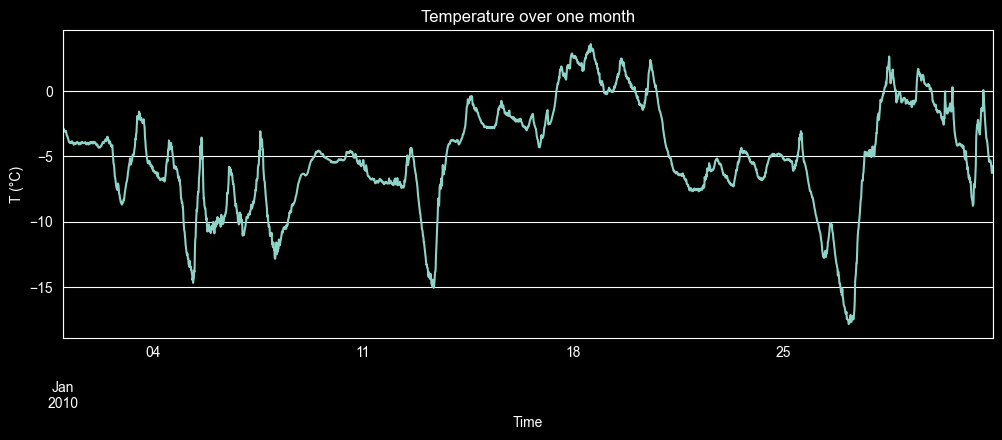

In [29]:
df["T_(degC)"].loc["2010-01-01":"2010-01-31"].plot(figsize=(12, 4))
plt.title("Temperature over one month")
plt.xlabel("Time")
plt.ylabel("T (°C)")
plt.show()

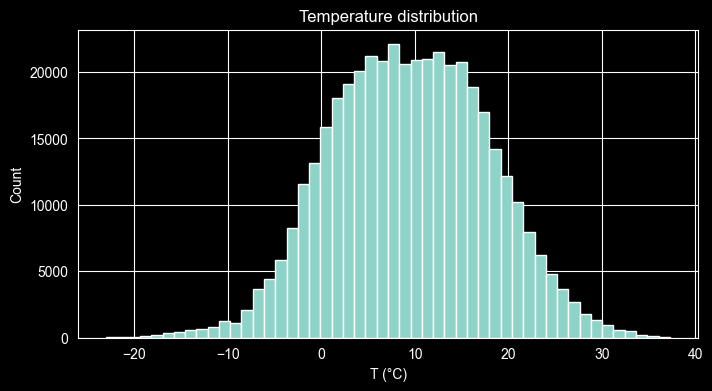

In [30]:
plt.figure(figsize=(8, 4))
plt.hist(df["T_(degC)"], bins=50)
plt.title("Temperature distribution")
plt.xlabel("T (°C)")
plt.ylabel("Count")
plt.show()

In [31]:
# Correlation matrix for the selected features
corr = df.corr(numeric_only=True)
display(corr)

,p_(mbar),T_(degC),rh_(%),sh_(g/kg),wv_(m/s),wd_(deg)
p_(mbar),1.000000,-0.045375,-0.018352,-0.069762,-0.209613,-0.063258
T_(degC),-0.045375,1.000000,-0.572416,0.866755,0.088368,0.038732
rh_(%),-0.018352,-0.572416,1.000000,-0.150841,-0.312213,-0.015912
sh_(g/kg),-0.069762,0.866755,-0.150841,1.000000,-0.065399,0.019376
wv_(m/s),-0.209613,0.088368,-0.312213,-0.065399,1.000000,-0.057787
wd_(deg),-0.063258,0.038732,-0.015912,0.019376,-0.057787,1.000000


## Preprocessing Pipeline

In this section we run the complete preprocessing pipeline implemented in `src/data/build_dataset.py`.

The pipeline performs:

1. Data loading (downloads the dataset automatically if needed)
2. Column cleaning and feature selection
3. Optional downsampling (e.g., hourly averages)
4. Sequential train/validation/test split (no shuffling)
5. Scaling using a scaler fitted on the training split only (prevents data leakage)
6. Sliding window generation for supervised learning

The resulting arrays are ready to be fed into a deep learning model:
- `x`: shape `(n_samples, window_size, n_features)`
- `y`: shape `(n_samples, horizon)`

In [32]:
# Hyperparameters (baseline run)
DOWNSAMPLE_TIME = "1h"
AGGREGATION_METHOD = 'mean'
MISSING_METHOD = 'interpolate'

TEST_RATIO = 0.15
VAL_RATIO = 0.15

WINDOW_SIZE = 72
TARGET_SIZE = 24

UNITS = 32
DROPOUT = 0.1

BATCH_SIZE = 128
EPOCHS = 100
SEED = 42

TARGET_FEATURE = "T_(degC)"

In [33]:
x_train, y_train, x_val, y_val, x_test, y_test, scaler = build_dataset(
    downsample_time=DOWNSAMPLE_TIME,
    aggregation_method=AGGREGATION_METHOD,
    missing_method=MISSING_METHOD,
    test_ratio=TEST_RATIO,
    val_ratio=VAL_RATIO,
    window_size=WINDOW_SIZE,
    target_size=TARGET_SIZE,
    target_feature=TARGET_FEATURE,
    save=True,  # keeps artifacts in data/processed and outputs/models
    reuse_scaler=False,
)

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_val:  ", x_val.shape, "y_val:  ", y_val.shape)
print("x_test: ", x_test.shape, "y_test: ", y_test.shape)

input_shape = x_train.shape[1:]  # (window_size, n_features)
output_size = y_train.shape[1]   # horizon

2026-03-05 15:08:56,519 | INFO | src.data.build_dataset | Building dataset (downsample_time=1h, window_size=72, target_size=24, target_feature=T_(degC))
2026-03-05 15:08:56,521 | INFO | src.data.download_data | Dataset already present: C:\Users\carlo\PycharmProjects\PythonProject\PythonProject\Deep-Learning-Weather-Forecasting\data\raw\jena_climate_2009_2016.csv
2026-03-05 15:08:56,522 | INFO | src.data.build_dataset | Loading raw CSV: C:\Users\carlo\PycharmProjects\PythonProject\PythonProject\Deep-Learning-Weather-Forecasting\data\raw\jena_climate_2009_2016.csv
2026-03-05 15:08:59,754 | INFO | src.data.build_dataset | Cleaning columns...
2026-03-05 15:08:59,755 | INFO | src.preprocessing.clean | Cleaning dataframe...
2026-03-05 15:08:59,824 | INFO | src.preprocessing.clean | Fixing 18 invalid wind-speed values (<0).
2026-03-05 15:08:59,834 | INFO | src.data.build_dataset | Downsampling with rule: 1h
2026-03-05 15:08:59,835 | INFO | src.preprocessing.resampling | Resampling dataframe t

x_train: (48996, 72, 6) y_train: (48996, 24)
x_val:   (10424, 72, 6) y_val:   (10424, 24)
x_test:  (10424, 72, 6) y_test:  (10424, 24)


## Model Training

We train a CNN + BiLSTM model for multistep forecasting.

- **Input:** past `WINDOW_SIZE` timesteps with all selected features
- **Output:** `TARGET_SIZE` temperature predictions (next 24 hours)

During training:
- Temporal order is preserved (`shuffle=False`)
- Early stopping is used to avoid overfitting
- The best model checkpoint is saved to `outputs/models/`

In [34]:
model = model_cnn_bilstm(
    units=UNITS,
    dropout_rate=DROPOUT,
    input_shape=input_shape,
    output_size=output_size,
)

model.summary()

2026-03-05 15:09:01,003 | INFO | src.models.build_model | Building model CNN_BiLSTM (units=32, dropout=0.100, input_shape=(72, 6), output_size=24)


Model: "CNN_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 72, 32)         │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 72, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 72, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 72, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,952 (113.09 KB)

 Trainable params: 28,888 (112.84 KB)

 Non-trainable params: 64 (256.00 B)

In [35]:
model, history = train_model(
    model=model,
    x_train=x_train,
    y_train=y_train,
    x_val=x_val,
    y_val=y_val,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    seed=SEED,
    checkpoint_dir=project_path("outputs", "models"),
)

2026-03-05 15:09:01,850 | INFO | src.models.train | Using callbacks: EarlyStopping(patience=10), ModelCheckpoint(C:\Users\carlo\PycharmProjects\PythonProject\PythonProject\Deep-Learning-Weather-Forecasting\outputs\models\CNN_BiLSTM.keras)
2026-03-05 15:09:01,852 | INFO | src.models.train | Training model 'CNN_BiLSTM' (epochs=100, batch_size=128, seed=42, shuffle=False)


Epoch 1/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 36s 74ms/step - loss: 0.6169 - root_mean_squared_error: 0.7854 - val_loss: 0.6488 - val_root_mean_squared_error: 0.8055
Epoch 2/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - loss: 0.2506 - root_mean_squared_error: 0.5006 - val_loss: 0.3939 - val_root_mean_squared_error: 0.6276
Epoch 3/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - loss: 0.1908 - root_mean_squared_error: 0.4368 - val_loss: 0.3253 - val_root_mean_squared_error: 0.5704
Epoch 4/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 41s 81ms/step - loss: 0.1666 - root_mean_squared_error: 0.4082 - val_loss: 0.2894 - val_root_mean_squared_error: 0.5379
Epoch 5/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 36s 68ms/step - loss: 0.1530 - root_mean_squared_error: 0.3911 - val_loss: 0.2780 - val_root_mean_squared_error: 0.5272
Epoch 6/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - loss: 0.1453 - root_mean_squared_error: 0.3812 - val_loss: 0.2545 - val_root_mean_squared_error: 0.5044
Epoch 7/100
383/383 ━━━━━━━━━━━━━━

## Evaluation and Results

We evaluate the trained model on the **test split**.

Evaluation includes:

- **Scaled metrics** reported by Keras (`test_loss`, `test_rmse`)
- **Unscaled metrics** on the original temperature units (°C):
  - Global RMSE / MAE (flattening all horizons)
  - Per-horizon RMSE / MAE (one value per forecast step)
- Visualization of:
  - Training curves
  - True vs predicted values for selected horizons
  - Random multi-step forecast samples
  - Metric evolution over the forecast horizon

In [36]:
results = evaluate_model(
    model=model,
    x_test=x_test,
    y_test_scaled=y_test,
    scaler=scaler,
    df_columns=df.columns,
    target_feature=TARGET_FEATURE,
)

print("\n============ METRICS ============")
print(f"Test Loss (scaled):   {results['test_loss']:.4f}")
print(f"Test RMSE (scaled):   {results['test_rmse']:.4f}")
print(f"RMSE (°C):            {results['rmse_global']:.4f}")
print(f"MAE (°C):             {results['mae_global']:.4f}")
print(f"Corr:                 {results['corr_global']:.4f}")
print(f"R2:                   {results['r2_global']:.4f}")

2026-03-05 15:30:08,912 | INFO | src.models.evaluate | Evaluating model on scaled test set...
2026-03-05 15:30:18,914 | INFO | src.preprocessing.scaling | Inverse-scaling feature 'T_(degC)' (index=1) for horizon=24.
2026-03-05 15:30:18,936 | INFO | src.preprocessing.scaling | Inverse-scaling feature 'T_(degC)' (index=1) for horizon=24.
2026-03-05 15:30:19,034 | INFO | src.models.evaluate | Evaluation complete | loss=0.2074 rmse_scaled=0.4555 rmse=3.9375 mae=3.0440 corr=0.9059 r2=0.7447



============ METRICS ============
Test Loss (scaled):   0.2074
Test RMSE (scaled):   0.4555
RMSE (°C):            3.9375
MAE (°C):             3.0440
Corr:                 0.9059
R2:                   0.7447


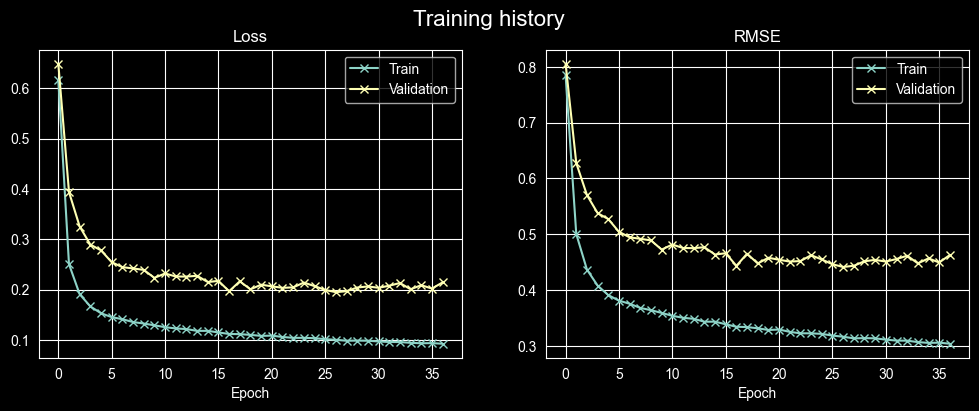

In [37]:
plot_training_history(history, show=True)

### Horizon-level inspection

To better understand multistep performance, we compare predictions vs ground truth
for selected forecast horizons (e.g., **h+1**, **h+12**, **h+24**).

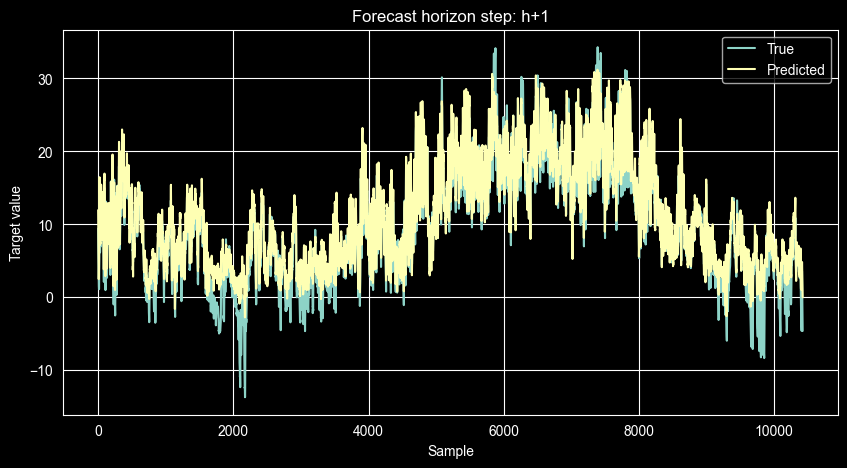

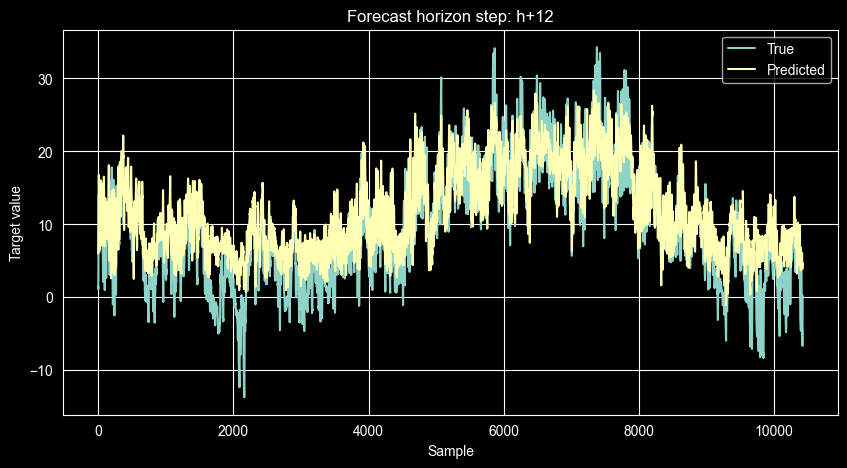

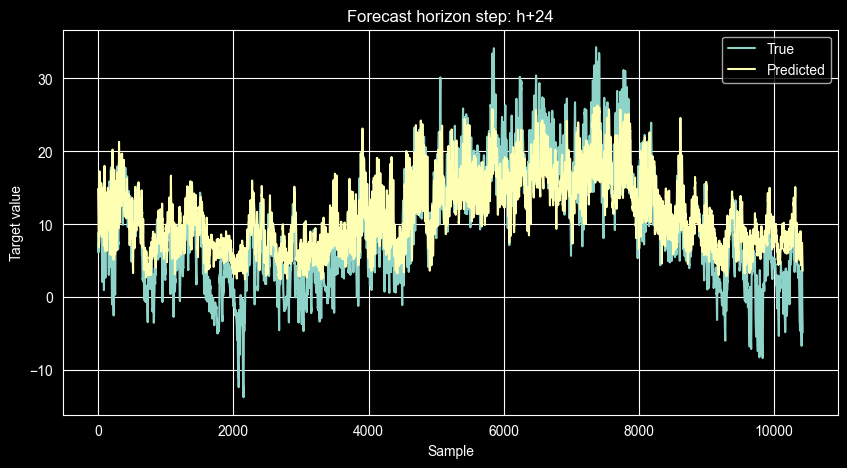

In [38]:
y_true = results["y_test_unscaled"]
y_pred = results["y_pred_unscaled"]

plot_horizon_comparison(y_true, y_pred, horizon_index=0, show=True)   # h+1
plot_horizon_comparison(y_true, y_pred, horizon_index=11, show=True)  # h+12
plot_horizon_comparison(y_true, y_pred, horizon_index=23, show=True)  # h+24

### Random multi-step forecast samples

We visualize a few random test samples and compare the full 24-hour prediction curve
against the true target trajectory.

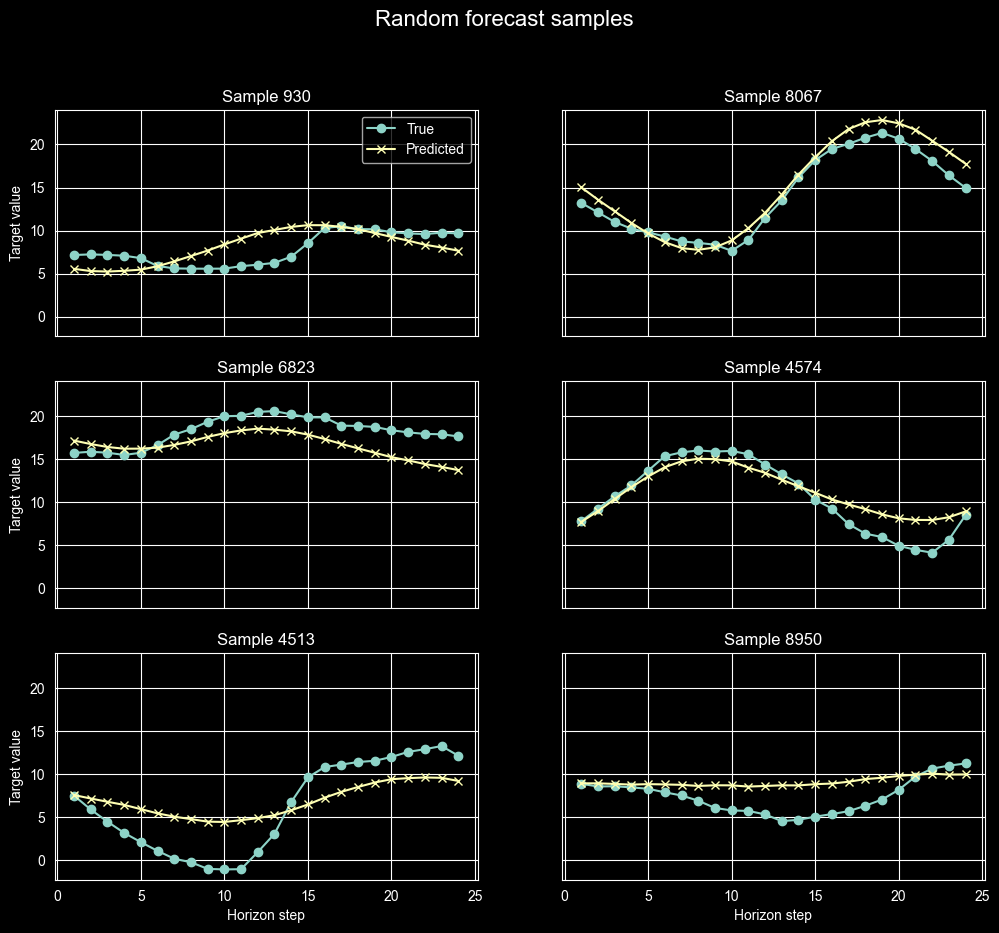

In [39]:
plot_random_samples(y_true, y_pred, seed=SEED, show=True)

### Metrics over the forecast horizon

Per-horizon metrics are the most informative for multistep forecasting,
since error typically increases with the prediction horizon.

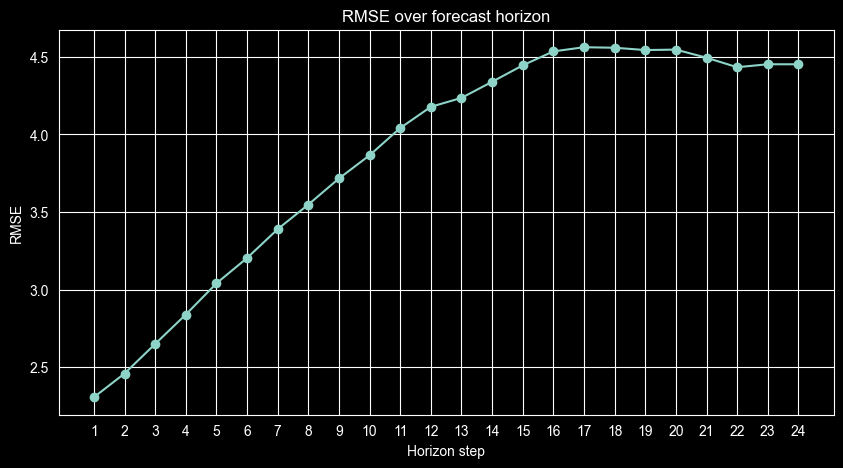

In [40]:
plot_metric_over_horizon(results["rmse_h"], "RMSE", show=True)

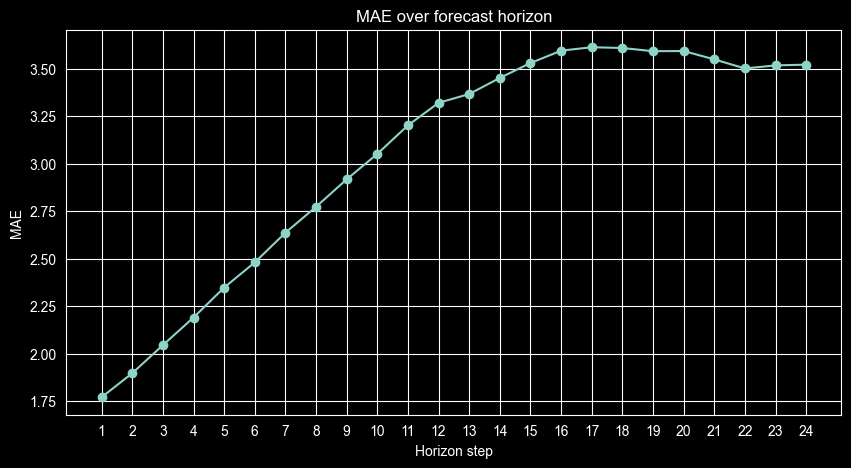

In [41]:
plot_metric_over_horizon(results["mae_h"], "MAE", show=True)

## Conclusions and Next Steps

### Summary
- The CNN + BiLSTM model achieves strong performance on the Jena Climate temperature forecasting task.
- Performance remains stable across the forecast horizon, with the expected degradation for longer horizons.

### Potential Improvements
- Add a **baseline** (e.g., persistence model) to quantify real gains over a trivial forecaster.
- Introduce a **config system** (`configs/`) to avoid editing code for experiments and to improve reproducibility.
- Add **tests** (shape checks, leakage checks, pipeline smoke tests).
- Explore additional architectures (pure LSTM, TCN, Transformer-based) and compare results systematically.